# Phase 1: CAISO 5-min LMP Exploration

**Goal**: Validate data quality, understand distributions, compute spike class frequencies, lock thresholds.

**Output**: Class frequency tables, threshold decisions, schema notes.

**Data**: 7-day sample from `data/processed/caiso_lmp_7d_sample.parquet` (5,799 rows × 11 cols, 247 KB).

**Status**: Phase 1 complete. Spike thresholds locked at 1.5x/3x/6x with 4h baseline. See `docs/PHASE1_FINDINGS.md` for full empirical report.

In [1]:
!unzip /content/dc_real_time_data.tar.gz

Archive:  /content/dc_real_time_data.tar.gz
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/dc_real_time_data.tar.gz or
        /content/dc_real_time_data.tar.gz.zip, and cannot find /content/dc_real_time_data.tar.gz.ZIP, period.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load 7-day sample
df = pd.read_parquet('/content/caiso_lmp_7d_sample.parquet')
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} cols")
print(df.head(3))

Loaded 5799 rows × 11 cols
                       Time            Interval Start  \
0 2026-06-27 19:40:00-07:00 2026-06-27 19:40:00-07:00   
1 2026-06-27 19:40:00-07:00 2026-06-27 19:40:00-07:00   
2 2026-06-27 19:40:00-07:00 2026-06-27 19:40:00-07:00   

               Interval End           Market          Location Location Type  \
0 2026-06-27 19:45:00-07:00  REAL_TIME_5_MIN  TH_NP15_GEN-APND   Trading Hub   
1 2026-06-27 19:45:00-07:00  REAL_TIME_5_MIN  TH_SP15_GEN-APND   Trading Hub   
2 2026-06-27 19:45:00-07:00  REAL_TIME_5_MIN  TH_ZP26_GEN-APND   Trading Hub   

        LMP    Energy  Congestion     Loss  GHG  
0  31.86544  17.12439    15.22225 -0.48120  0.0  
1  19.83033  17.12439     3.29674 -0.59079  0.0  
2  29.29346  17.12439    12.74445 -0.57538  0.0  


In [3]:
# Per-zone LMP stats
print("\n=== LMP stats per zone (7 days) ===")
print(df.groupby('Location')['LMP'].describe())


=== LMP stats per zone (7 days) ===
                   count       mean        std       min      25%       50%  \
Location                                                                      
TH_NP15_GEN-APND  1933.0  14.509010  13.149336 -12.58687  5.83834  15.29007   
TH_SP15_GEN-APND  1933.0   9.211151  12.520406 -20.86644 -0.34360  10.72276   
TH_ZP26_GEN-APND  1933.0  11.061473  12.953881 -19.62803  0.27931  13.10219   

                       75%        max  
Location                               
TH_NP15_GEN-APND  23.56494  126.93346  
TH_SP15_GEN-APND  20.26558   39.93299  
TH_ZP26_GEN-APND  22.12347   68.94703  


In [5]:
# Multi-class spike label function
def label_spike(lmp_series, window='4h', thresholds=(1.5, 3.0, 6.0)):
    baseline = lmp_series.rolling(window).mean()
    ratio = lmp_series / baseline
    labels = pd.cut(ratio, bins=[0, *thresholds, float('inf')], labels=[0,1,2,3], right=False)
    return labels.astype('Int64')

# Apply per zone
print("\n=== Spike class frequency (4h baseline, 1.5x/3x/6x) ===")
for loc, sub in df.groupby('Location'):
    sub = sub.sort_values('Time').set_index('Time')
    labels = label_spike(sub['LMP'])
    total = len(labels.dropna())
    print(f"\n{loc}:")
    for cls, name in {0:'Normal',1:'Moderate',2:'High',3:'Extreme'}.items():
        n = (labels == cls).sum()
        print(f"  Class {cls} ({name:8s}): {n:5d} ({n/total*100:5.2f}%)")


=== Spike class frequency (4h baseline, 1.5x/3x/6x) ===

TH_NP15_GEN-APND:
  Class 0 (Normal  ):  1537 (84.27%)
  Class 1 (Moderate):   212 (11.62%)
  Class 2 (High    ):    48 ( 2.63%)
  Class 3 (Extreme ):    27 ( 1.48%)

TH_SP15_GEN-APND:
  Class 0 (Normal  ):  1408 (81.67%)
  Class 1 (Moderate):   209 (12.12%)
  Class 2 (High    ):    65 ( 3.77%)
  Class 3 (Extreme ):    42 ( 2.44%)

TH_ZP26_GEN-APND:
  Class 0 (Normal  ):  1396 (81.21%)
  Class 1 (Moderate):   205 (11.93%)
  Class 2 (High    ):    79 ( 4.60%)
  Class 3 (Extreme ):    39 ( 2.27%)


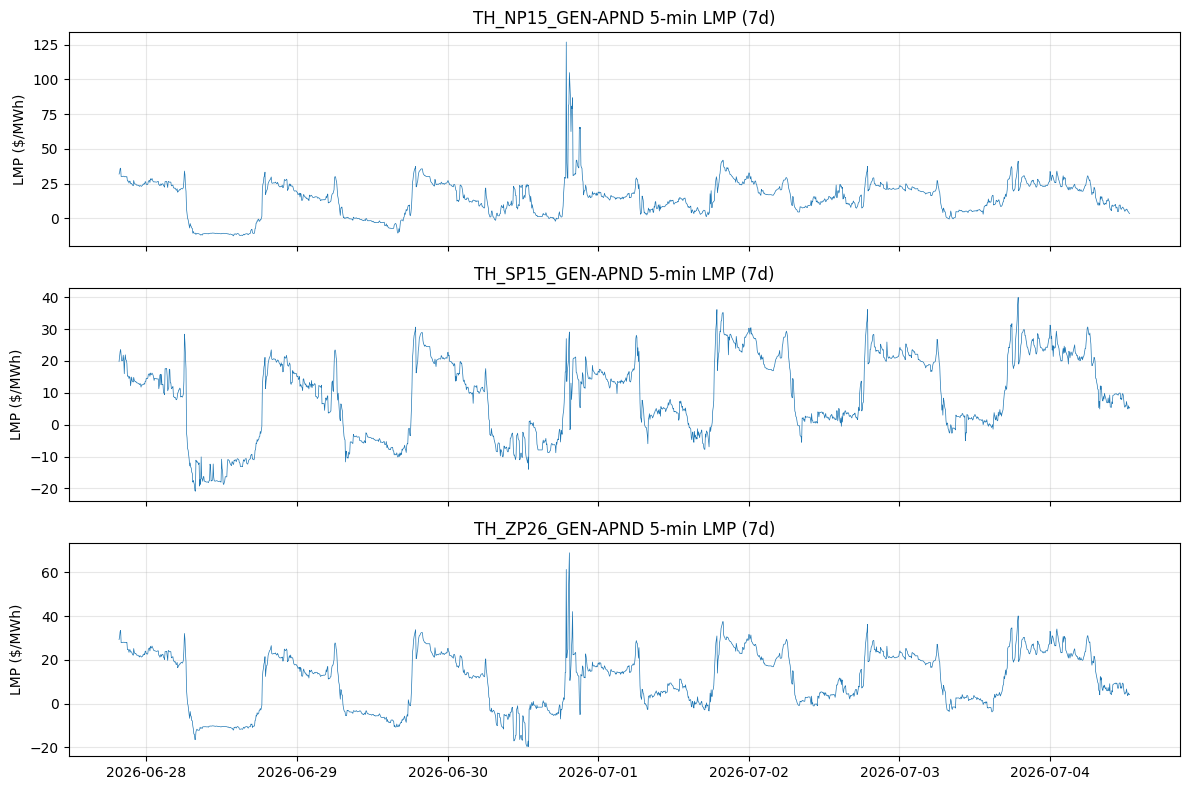

In [6]:
# Visualization: 24h LMP trace per zone
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (loc, sub) in enumerate(df.groupby('Location')):
    sub = sub.sort_values('Time')
    ax[i].plot(sub['Time'], sub['LMP'], linewidth=0.5)
    ax[i].set_title(f'{loc} 5-min LMP (7d)')
    ax[i].set_ylabel('LMP ($/MWh)')
    ax[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/lmp_7d_trace.png', dpi=100)
plt.show()

## Findings Summary

| Zone | Mean LMP | Std LMP | Max LMP | Class 3 (Extreme) % |
|------|----------|---------|---------|--------------------|
| NP15 | $14.51 | $13.15 | $126.93 | 1.48% |
| SP15 | $9.21 | $12.52 | $39.93 | 2.44% |
| ZP26 | $11.06 | $12.95 | $68.95 | 2.27% |

**Decisions locked** (see DECISIONS.md):
- D1: Multi-class spike classifier with 4 levels
- D8: Thresholds = 1.5x / 3.0x / 6.0x with 4h rolling baseline
- D9: Use `caiso.get_lmp(date=...)` for backfill (range mode broken in OASIS)
- D10: GHG (carbon intensity) is system-wide, not per-zone

**Next steps**:
- Run `notebooks/colab_handoff/01_caiso_1y_backfill.md` on Colab Pro for 1y history
- Then: Phase 2 (feature engineering), Phase 3 (XGBoost baseline)

In [7]:
# How much history to pull
HISTORY_DAYS = 365  # Full year
# HISTORY_DAYS = 180  # Half year (CAISO retains ~90-180d reliably)
# HISTORY_DAYS = 90   # Just the last 3 months (fastest, but limits training)

# Which CAISO trading hubs
ZONES = ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND']
# TH_NP15 = Northern California (PG&E)
# TH_SP15 = Southern California (SCE/SDG&E)
# TH_ZP26 = Central California (avoided cost zone)

In [8]:
!pip install gridstatus pyarrow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.2/551.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 9

In [9]:


import gridstatus
import pandas as pd
from datetime import datetime, timedelta
import time

caiso = gridstatus.CAISO()

# === 1. Pull LMP for 1 year ===
print("Pulling LMP...")
end = datetime.now() - timedelta(days=1)
lmp_dfs = []
t0 = time.time()
for i in range(HISTORY_DAYS, 0, -1):
    d = end - timedelta(days=i-1)
    try:
        lmp = caiso.get_lmp(date=d, market='REAL_TIME_5_MIN')
        lmp_dfs.append(lmp)
        if i % 30 == 0:
            print(f"  {HISTORY_DAYS - i + 1}/{HISTORY_DAYS} days pulled ({time.time()-t0:.0f}s)")
    except Exception as e:
        print(f"  {d.date()}: skipped ({e})")

lmp_df = pd.concat(lmp_dfs, ignore_index=True)
print(f"LMP: {lmp_df.shape}, memory: {lmp_df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
lmp_df.to_parquet('caiso_lmp_1y.parquet')
print(f"Saved caiso_lmp_1y.parquet ({lmp_df.memory_usage(deep=True).sum()/1024**2:.1f} MB)")

# === 2. Pull fuel mix for 1 year ===
print("\nPulling fuel mix...")
fm_dfs = []
for i in range(HISTORY_DAYS, 0, -1):
    d = end - timedelta(days=i-1)
    try:
        fm = caiso.get_fuel_mix(date=d)
        fm_dfs.append(fm)
    except Exception as e:
        print(f"  {d.date()}: skipped ({e})")

fm_df = pd.concat(fm_dfs, ignore_index=True)
print(f"Fuel mix: {fm_df.shape}")
fm_df.to_parquet('caiso_fuel_mix_1y.parquet')

# === 3. Verify data ===
print("\n=== LMP stats ===")
print(lmp_df.groupby('Location')['LMP'].describe())
print("\n=== Fuel mix means (MW) ===")
fuel_cols = [c for c in fm_df.columns if c not in ['Time','Interval Start','Interval End']]
print(fm_df[fuel_cols].mean().sort_values(ascending=False))

# === 4. Download ===
from google.colab import files
files.download('caiso_lmp_1y.parquet')
files.download('caiso_fuel_mix_1y.parquet')

2026-07-04 21:28:23 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
DEBUG:gridstatus:Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-07-04 21:28:23 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_LMP&version=3&market_run_id=RTM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APND,TH_ZP26_GEN-APND&startdatetime=20250705T04:28-0000&enddatetime=20250706T04:28-0000
INFO:gridstatus:Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_LMP&version=3&market_run_id=RTM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APND,TH_ZP26_GEN-APND&startdatetime=20250705T04:28-0000&enddatetime=20250706T04:28-0000


Pulling LMP...


2026-07-04 21:28:28 - DEBUG - Found 1 files: ['20250704_20250705_PRC_INTVL_LMP_RTM_20260704_14_28_24_v3.csv']
DEBUG:gridstatus:Found 1 files: ['20250704_20250705_PRC_INTVL_LMP_RTM_20260704_14_28_24_v3.csv']
2026-07-04 21:28:28 - DEBUG - Parsing file: 20250704_20250705_PRC_INTVL_LMP_RTM_20260704_14_28_24_v3.csv
DEBUG:gridstatus:Parsing file: 20250704_20250705_PRC_INTVL_LMP_RTM_20260704_14_28_24_v3.csv
2026-07-04 21:28:33 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
DEBUG:gridstatus:Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-07-04 21:28:33 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_LMP&version=3&market_

  6/365 days pulled (56s)


2026-07-04 21:29:23 - DEBUG - Found 1 files: ['20250710_20250711_PRC_INTVL_LMP_RTM_20260704_14_29_20_v3.csv']
DEBUG:gridstatus:Found 1 files: ['20250710_20250711_PRC_INTVL_LMP_RTM_20260704_14_29_20_v3.csv']
2026-07-04 21:29:23 - DEBUG - Parsing file: 20250710_20250711_PRC_INTVL_LMP_RTM_20260704_14_29_20_v3.csv
DEBUG:gridstatus:Parsing file: 20250710_20250711_PRC_INTVL_LMP_RTM_20260704_14_29_20_v3.csv
2026-07-04 21:29:28 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
DEBUG:gridstatus:Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_LMP', 'version': 3}, 'params': {'market_run_id': 'RTM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-07-04 21:29:28 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_LMP&version=3&market_

...

Fuel mix: (105108, 16)

=== LMP stats ===
                     count       mean        std        min        25%  \
Location                                                                 
TH_NP15_GEN-APND  105047.0  31.942897  24.192541  -76.56573  21.068615   
TH_SP15_GEN-APND  105047.0  26.303690  27.772192  -66.26464  12.425765   
TH_ZP26_GEN-APND  105047.0  26.908959  23.765914 -105.95410  13.751630   

                       50%        75%        max  
Location                                          
TH_NP15_GEN-APND  32.87225  43.133620  1149.8080  
TH_SP15_GEN-APND  28.23551  39.743915  1148.1915  
TH_ZP26_GEN-APND  29.51641  40.637470  1130.0824  

=== Fuel mix means (MW) ===
Solar          6651.259895
Natural Gas    5294.211297
Imports        4224.235948
Wind           2684.066189
Large Hydro    2141.317350
Nuclear        2130.182365
Geothermal      724.351343
Small Hydro     254.960926
Biomass         217.561660
Biogas          160.177332
Coal              0.000000
Other 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>